In [1]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=2.5)

In [2]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 7, 2, 0.5, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [3]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


<Axes: >

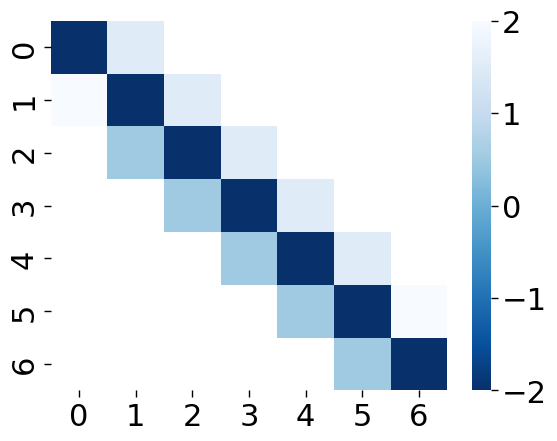

In [40]:

sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) , cmap = "Blues_r")

<Axes: >

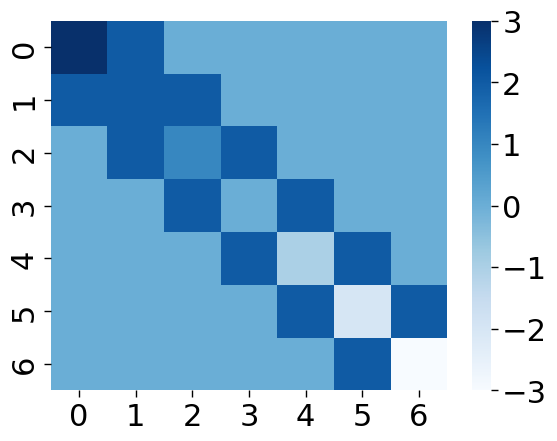

In [37]:
sns.heatmap(-np.imag(intensity_matrix_quantum.squeeze()), cmap = "Blues")

In [6]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Uniform")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Uniform")
phi_0_markov, phi_0_quantum

(Array([[[[0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714]]]], dtype=float64),
 Array([[[[0.37796447],
          [0.37796447],
          [0.37796447],
          [0.37796447],
          [0.37796447],
          [0.37796447],
          [0.37796447]]]], dtype=float64))

In [7]:
ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[0.5]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

Array([[[[0.07537035],
         [0.13750291],
         [0.14365105],
         [0.14388377],
         [0.14989734],
         [0.20894652],
         [0.14074806]]]], dtype=float64)

phi_0_quantum = npx.array([[[[0.06871463],
         [0.07356508],
         [0.08124495],
         [0.10388036],
         [0.12732417],
         [0.11843169],
         [0.10549717],
         [0.09700889],
         [0.08124495],
         [0.06911884],
         [0.07396928]]]])
phi_0_quantum.shape

In [8]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
    
    for t in np.arange(1,5/delta,delta):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,5/delta,delta):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [9]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d = df_quantum_3d.assign(time=lambda df: df.time * 0.1)
df_quantum_3d

,states,prior,time,real,imag
0,-3,Upper,0.0,0.015806231610739206,-0.07284835683223474
1,-2,Upper,0.0,0.13267102392865185,-0.07284835683223476
2,-1,Upper,0.0,0.2258264688304557,0.08098423504194313
3,0,Upper,0.0,0.19480782793407878,0.18424849839679902
4,1,Upper,0.0,0.3378279939164369,0.27867265704081373
...,...,...,...,...,...
373,-1,Lower,1.7,0.16825518327631722,-0.2072893685180953
374,0,Lower,1.7,-0.3947346608839099,-0.3480653835907215
375,1,Lower,1.7,-0.06683698706690663,0.632452186046755
376,2,Lower,1.7,0.250122562796362,-0.12735716226937518


In [10]:
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype+notebook'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [11]:
import plotly.express as px
pio.renderers.default = "vscode" #"browser" #
fig = px.line_3d(df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Uniform' and time < 30").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), 
                 x="Time", y="Real", z="Imaginary", color="state_labels", title = 'Random Walk - Probability "Amplitude" (Participant #1)',
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Conf States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=10
    ))
fig.update_layout(
    legend_title_font=dict(size=50, color="black"),
    title_font=dict(size=60, color="black"),
    font=dict(
        
        size=20,  # Set the font size here
    ))
fig.update_scenes(
    xaxis=dict(title='Observed time (in secs)', tickfont=dict(size=15), titlefont=dict(size=45)),
    yaxis=dict(title='Real', tickfont=dict(size=15), titlefont=dict(size=45)),
    zaxis=dict(title='Imaginary', tickfont=dict(size=15), titlefont=dict(size=45)),
)
fig.layout.template = "seaborn"
#fig.show()
import plotly.io as pio
#pio.write_image(fig, 'image.png',format="png",scale=1, width=1080, height=1080)

In [12]:
df_quantum_3d.query("states == 6 and prior == 'Upper' and time > 10 and time < 100")

,states,prior,time,real,imag


In [13]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [14]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov*20).squeeze())

,0,1,2,3,4,5,6
0,0.001380,0.001378,0.001376,0.001375,0.001374,0.001373,0.001373
1,0.005514,0.005509,0.005503,0.005498,0.005495,0.005494,0.005494
2,0.016516,0.016508,0.016497,0.016489,0.016484,0.016483,0.016482
3,0.049489,0.049480,0.049467,0.049457,0.049452,0.049449,0.049449
4,0.148371,0.148366,0.148360,0.148355,0.148352,0.148351,0.148351
5,0.444997,0.445011,0.445031,0.445045,0.445053,0.445057,0.445057
6,0.333733,0.333747,0.333767,0.333781,0.333790,0.333793,0.333793


In [15]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))

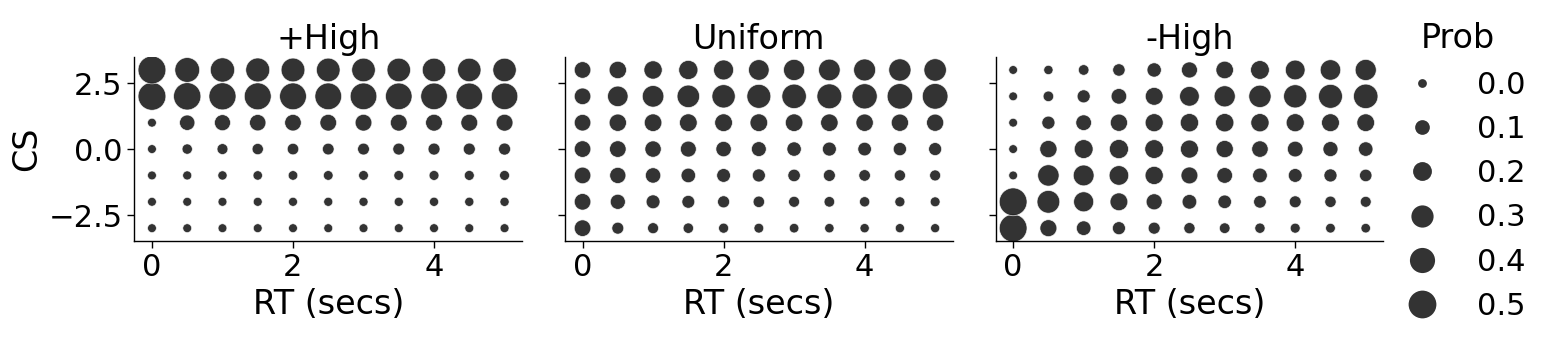

In [16]:
with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_markov_plot
                    .query("time <= 5")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()


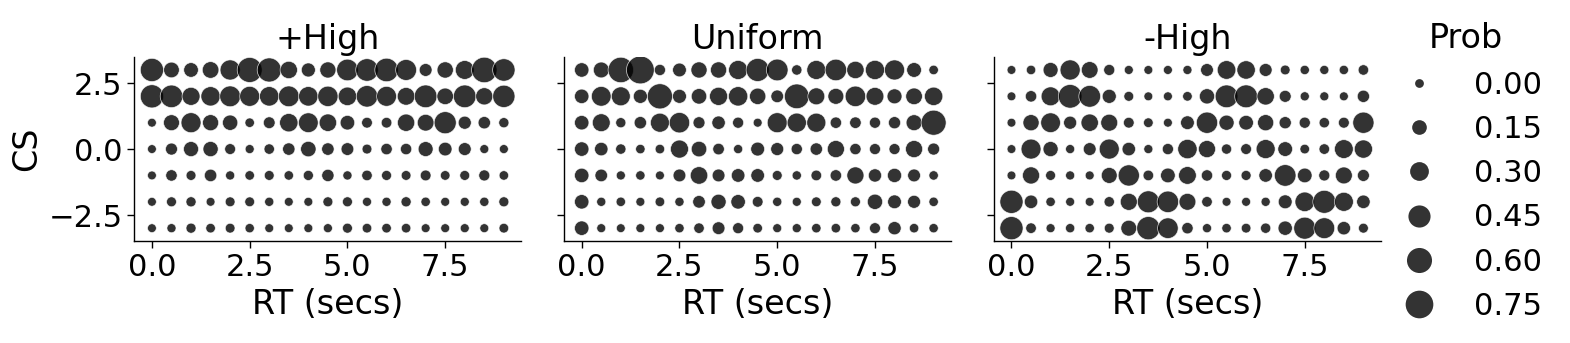

In [17]:
with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_quantum_plot
                    .query("time <= 15")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [18]:
df_plot = pd.concat([df_markov_plot.assign(type="Diffusion Random-Walk Model"), df_quantum_plot.assign(type="Quantum Random-Walk Model")])
df_plot

,states,prior,time,value,type
0,-3,+High,0.0,0.000000,Diffusion Random-Walk Model
1,-2,+High,0.0,0.000000,Diffusion Random-Walk Model
2,-1,+High,0.0,0.000000,Diffusion Random-Walk Model
3,0,+High,0.0,0.000000,Diffusion Random-Walk Model
4,1,+High,0.0,0.000000,Diffusion Random-Walk Model
...,...,...,...,...,...
394,-1,-High,9.0,0.071279,Quantum Random-Walk Model
395,0,-High,9.0,0.276965,Quantum Random-Walk Model
396,1,-High,9.0,0.404463,Quantum Random-Walk Model
397,2,-High,9.0,0.078781,Quantum Random-Walk Model


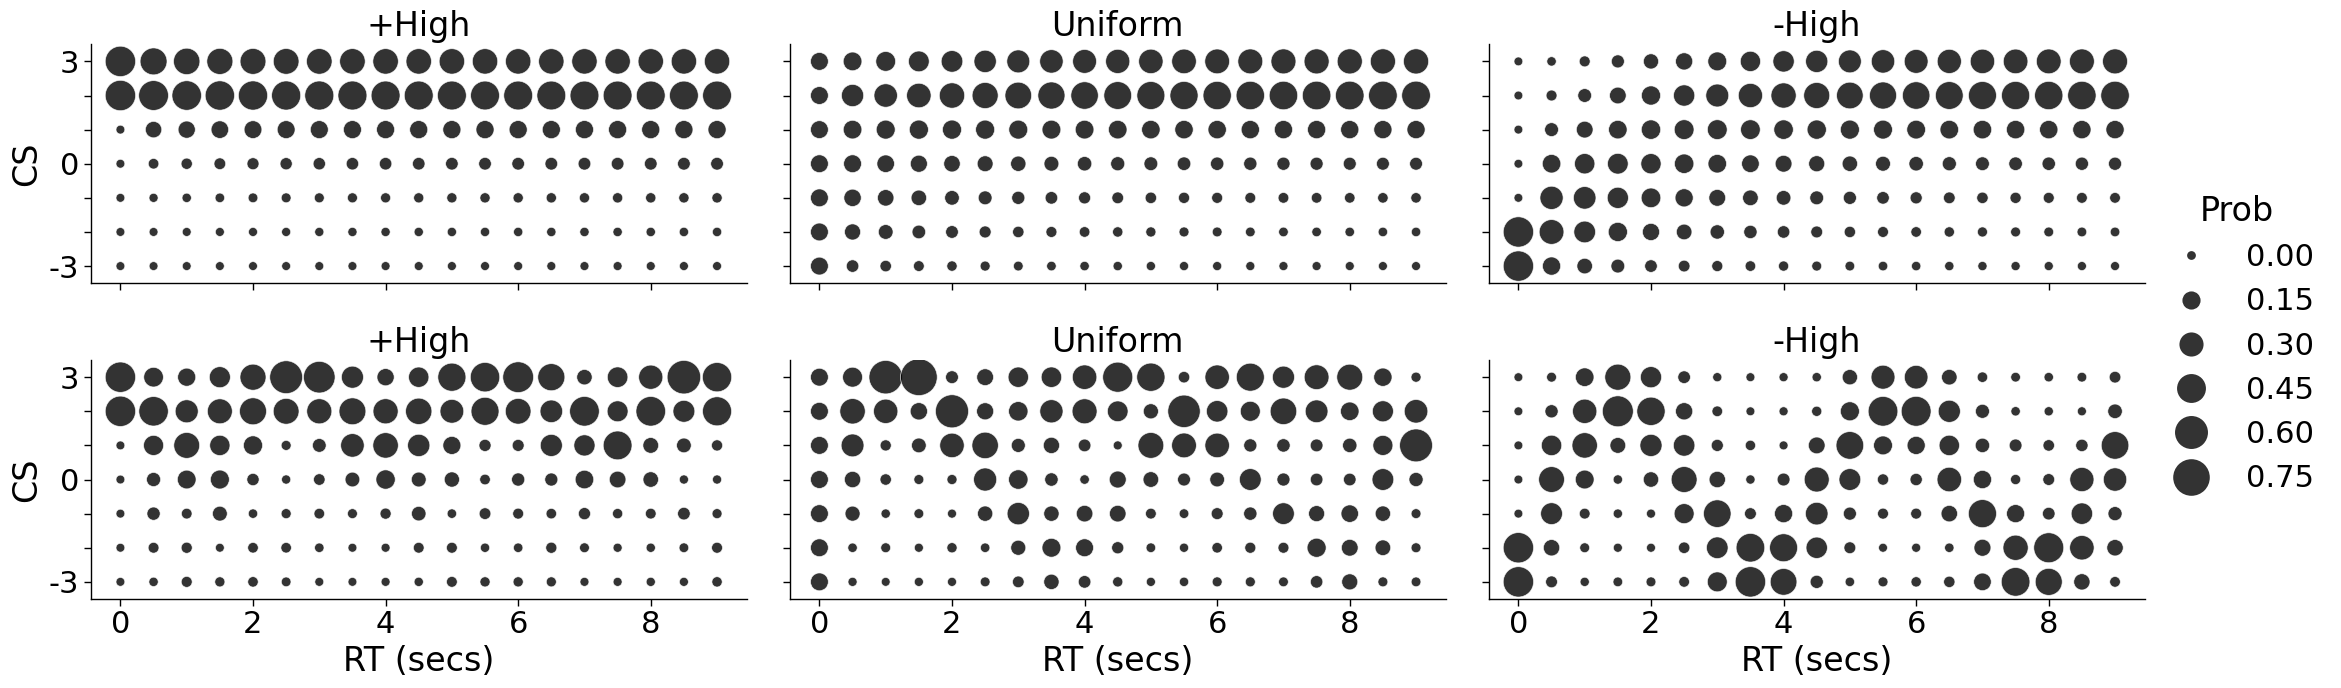

In [19]:
with sns.plotting_context(font_scale=1):
    f = sns.relplot(df_plot
                    .query("time <= 20 ")
                    ,alpha=0.8, row="type", col="prior", sizes=(40,700), 
    x="time", y="states",size="value", color="Black", aspect=2, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

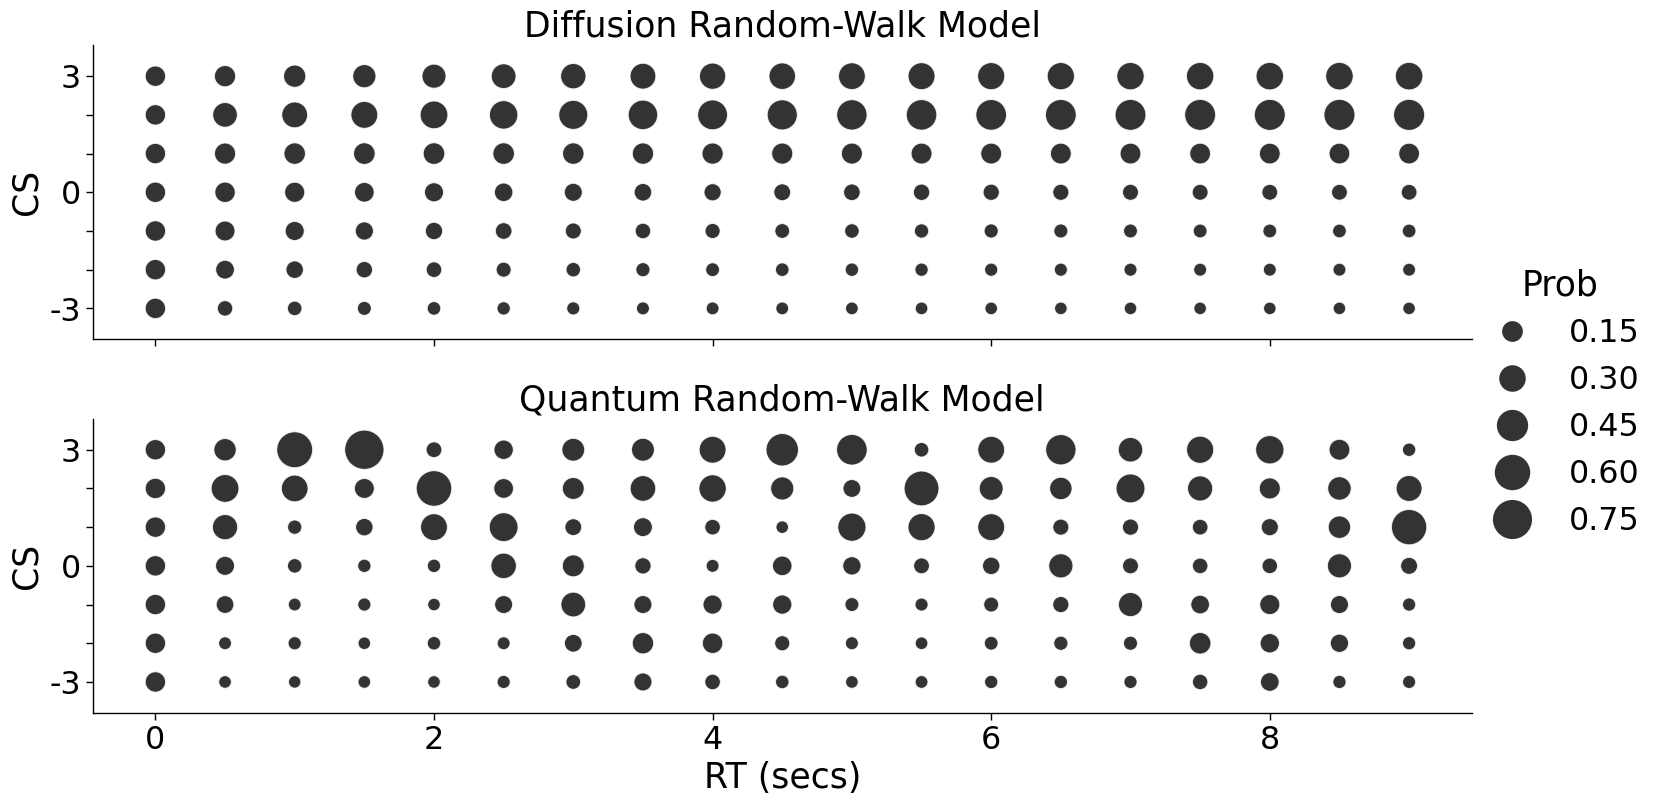

In [20]:
with sns.plotting_context("paper",font_scale=2.6):
    f = sns.relplot(df_plot
                    .query("prior == 'Uniform' and time <= 20 ")
                    ,alpha=0.8, col="type", col_wrap=1, sizes=(80,800), 
    x="time", y="states",size="value", color="Black", aspect=3.6, height=4.3)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-3.8, 3.8))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [21]:
import matplotlib as mpl
mpl.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

In [22]:
mid = int(n_states+1)/2
states_ticks = np.arange(-(mid-1), mid)
states_labels = (states_ticks + (5 * np.sign(states_ticks))) * 10
states_labels

array([-80., -70., -60.,   0.,  60.,  70.,  80.])

df_quantum_plot.groupby(["time", "prior"], sort=False)[["value", "states"]].apply(lambda df: df.value * df.states)#.values

def test(df):
    #print((df.value * df.state_labels).values.shape)
    return (df.value * df.state_labels).values
df_quantum_plot.query("prior=='Uniform' and time < 15") \
.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ) \
.assign(mean_conf = lambda df: df.groupby(["time", "prior"], sort=False)[["value", "state_labels"]].apply(lambda df: df.value * df.state_labels).values)

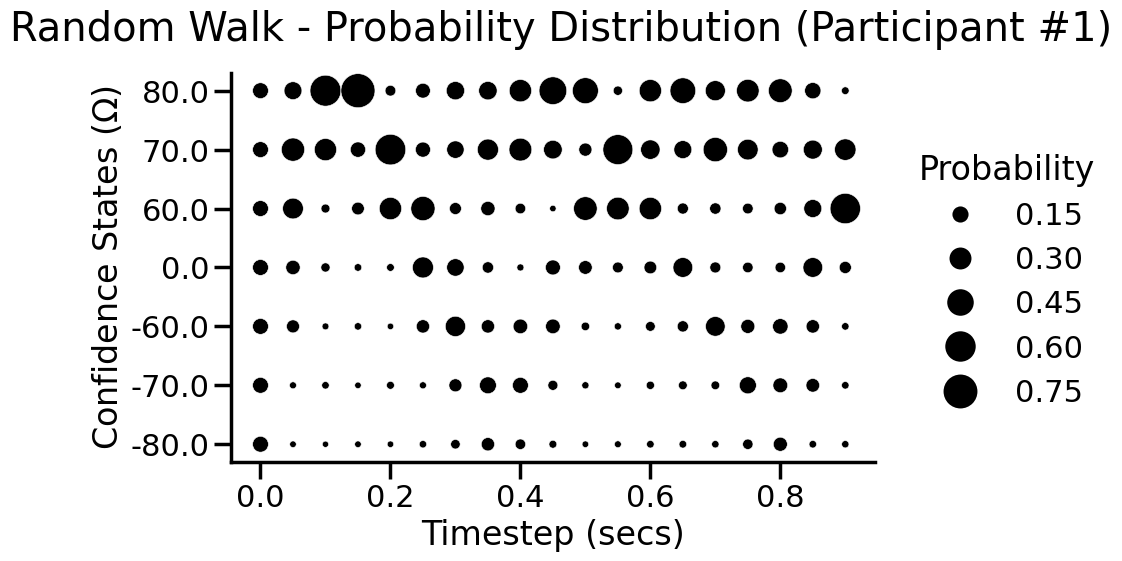

In [23]:
with sns.plotting_context(context="poster"):
    f = sns.relplot(df_quantum_plot.query("prior=='Uniform' and time < 18.24").assign(time = lambda df: df.time * 0.1), 
    x="time", y="states",size="value", legend=True, sizes=(20,600), aspect=1.5, color="black", height=5.5 )
    f.set(yticks = states_ticks)
    f.set_yticklabels(labels=states_labels)
    f.set_ylabels(r"Confidence States $(\Omega)$")
    f.set_xlabels("Timestep (secs)")
    f.legend.set_title("Probability")
    f.figure.suptitle("Random Walk - Probability Distribution (Participant #1)", y=1.05)


In [24]:
fig = px.scatter(df_quantum_plot.query("prior=='Uniform'"), x="time", y="states",size="value")
fig.update_layout( 
    scene=dict(aspectratio = dict( x=1, y=0.1 ),
    aspectmode = 'manual'),
    autosize=True)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'time=%{x}<br>states=%{y}<br>value=%{marker.size}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa',
                         'size': array([1.42857143e-01, 1.42857143e-01, 1.42857143e-01, 1.42857143e-01,
                                        1.42857143e-01, 1.42857143e-01, 1.42857143e-01, 3.15589310e-03,
                                        6.77717535e-03, 8.79194258e-02, 1.12859408e-01, 2.63141973e-01,
                                        3.37391962e-01, 1.88754163e-01, 3.99568078e-04, 1.18040617e-02,
                                        5.73649947e-03, 3.09571212e-02, 2.76138892e-02, 3.04998979e-01,
                                        6.18489881e-01, 3.28182573e-03, 2.48376166e-03, 1.09468855e-02,
                                        1.26093021e-02, 8.24861943e-02, 1.31768360e-01, 7.56423671e-01,
                                        2.66543500e-03, 1.58034769e-02, 2.28259381e-03, 1.40053239e-02,
                                        3.09037990e-01, 6.04699523e-01, 5.15056576e-02, 1.09202474e-02,
                                        7.48951416e-03, 9.29059047e-02, 2.70694535e-01, 3.69193015e-01,
                                        1.27258751e-01, 1.21538032e-01, 3.48802828e-02, 8.81567846e-02,
                                        2.50220762e-01, 1.78628170e-01, 7.05949681e-02, 1.77663883e-01,
                                        1.99855149e-01, 9.35393689e-02, 1.65389801e-01, 9.33626753e-02,
                                        6.07567436e-02, 1.11063114e-01, 2.73651422e-01, 2.02236876e-01,
                                        4.81824944e-02, 1.44298440e-01, 1.17064592e-01, 7.56057147e-03,
                                        4.90319044e-02, 3.24256435e-01, 3.09605562e-01, 1.58634904e-02,
                                        4.14276476e-02, 1.17978204e-01, 1.24697613e-01, 2.11163890e-03,
                                        2.07508228e-01, 4.90413178e-01, 3.39253699e-03, 8.80315411e-03,
                                        2.25720931e-02, 9.93263645e-02, 3.48647151e-01, 8.98883888e-02,
                                        4.27370312e-01, 5.81441318e-03, 4.26872093e-03, 9.27299079e-03,
                                        5.27746650e-02, 3.17956351e-01, 5.77761595e-01, 3.21512641e-02,
                                        1.24911794e-02, 1.98439175e-02, 3.81861831e-02, 8.25945287e-02,
                                        3.11097600e-01, 2.27602622e-01, 3.08183970e-01, 1.33838532e-02,
                                        2.61643992e-02, 5.89717040e-02, 2.35820471e-01, 5.67963489e-02,
                                        1.90569005e-01, 4.18294219e-01, 1.07332560e-02, 2.46621870e-02,
                                        2.33478299e-01, 5.48968293e-02, 6.03841858e-02, 3.71753968e-01,
                                        2.44091275e-01, 4.64241884e-02, 1.69771681e-01, 1.06697711e-01,
                                        4.84063172e-02, 5.05208231e-02, 2.60522717e-01, 3.17656562e-01,
                                        1.06913055e-01, 1.20905923e-01, 1.35394847e-01, 4.81022857e-02,
                                        7.69864261e-02, 1.58394659e-01, 3.53302805e-01, 1.21385965e-02,
                                        9.89714352e-02, 9.44005790e-02, 2.34099949e-01, 1.91438451e-01,
                                        2.16472537e-01, 1.52478453e-01, 1.00891031e-02, 1.19774773e-02,
                                        1.16839656e-02, 7.30153395e-02, 5.95974702e-01, 2.83315982e-01,
                                        1.39434299e-02]),
                         'sizemode': 'area',
                         'sizeref': 0.0018910591762814988,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              

f = sns.relplot(df_quantum_plot.astype({"states":"category"}),
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1, height = 4.5)
f.set_titles("{col_name}")
f.legend.set_title("Probability")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_loc("lower right")

In [25]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

array([-3, -2, -1,  0,  1,  2,  3])

In [26]:
start_width

2

In [27]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

for mu in [npx.asarray([[0.05]]), npx.asarray([[-0.05]]), npx.asarray([[1]]), npx.asarray([[-1]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, mu, q_sigma)
    print(intensity_matrix_markov)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []

        #phi_markov_arr.append(np.asarray(phi_0_markov.squeeze() @ mv))
        #phi_quantum_arr.append((np.abs(phi_0_quantum.squeeze())**2) @ mv)


        for t in np.arange(1,20,0.1):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in np.arange(1,20,0.1):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=f"$v$={np.asarray(mu[0,0])}, $\sigma$={np.asarray(m_sigma[0,0])}")])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=f"$v$={np.asarray(mu[0,0])}, $\sigma$={np.asarray(m_sigma[0,0])}")])
        

[[[[-2.     0.975  0.     0.     0.     0.     0.   ]
   [ 2.    -2.     0.975  0.     0.     0.     0.   ]
   [ 0.     1.025 -2.     0.975  0.     0.     0.   ]
   [ 0.     0.     1.025 -2.     0.975  0.     0.   ]
   [ 0.     0.     0.     1.025 -2.     0.975  0.   ]
   [ 0.     0.     0.     0.     1.025 -2.     2.   ]
   [ 0.     0.     0.     0.     0.     1.025 -2.   ]]]]
[[[[-2.     1.025  0.     0.     0.     0.     0.   ]
   [ 2.    -2.     1.025  0.     0.     0.     0.   ]
   [ 0.     0.975 -2.     1.025  0.     0.     0.   ]
   [ 0.     0.     0.975 -2.     1.025  0.     0.   ]
   [ 0.     0.     0.     0.975 -2.     1.025  0.   ]
   [ 0.     0.     0.     0.     0.975 -2.     2.   ]
   [ 0.     0.     0.     0.     0.     0.975 -2.   ]]]]
[[[[-2.   0.5  0.   0.   0.   0.   0. ]
   [ 2.  -2.   0.5  0.   0.   0.   0. ]
   [ 0.   1.5 -2.   0.5  0.   0.   0. ]
   [ 0.   0.   1.5 -2.   0.5  0.   0. ]
   [ 0.   0.   0.   1.5 -2.   0.5  0. ]
   [ 0.   0.   0.   0.   1.5 -2.   2. 

In [28]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1).assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1).assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_markov1_plot.query("value > 3")

,prior,mu,time,value


In [29]:
df_markov1_plot

,prior,mu,time,value
0,+High,"$v$=0.05, $\sigma$=2",0.0,1.823316
1,Uniform,"$v$=0.05, $\sigma$=2",0.0,0.032856
2,-High,"$v$=0.05, $\sigma$=2",0.0,-1.773428
3,+High,"$v$=-0.05, $\sigma$=2",0.0,1.773428
4,Uniform,"$v$=-0.05, $\sigma$=2",0.0,-0.032856
...,...,...,...,...
2275,Uniform,"$v$=1, $\sigma$=2",18.9,2.008117
2276,-High,"$v$=1, $\sigma$=2",18.9,2.007908
2277,+High,"$v$=-1, $\sigma$=2",18.9,-2.007908
2278,Uniform,"$v$=-1, $\sigma$=2",18.9,-2.008117


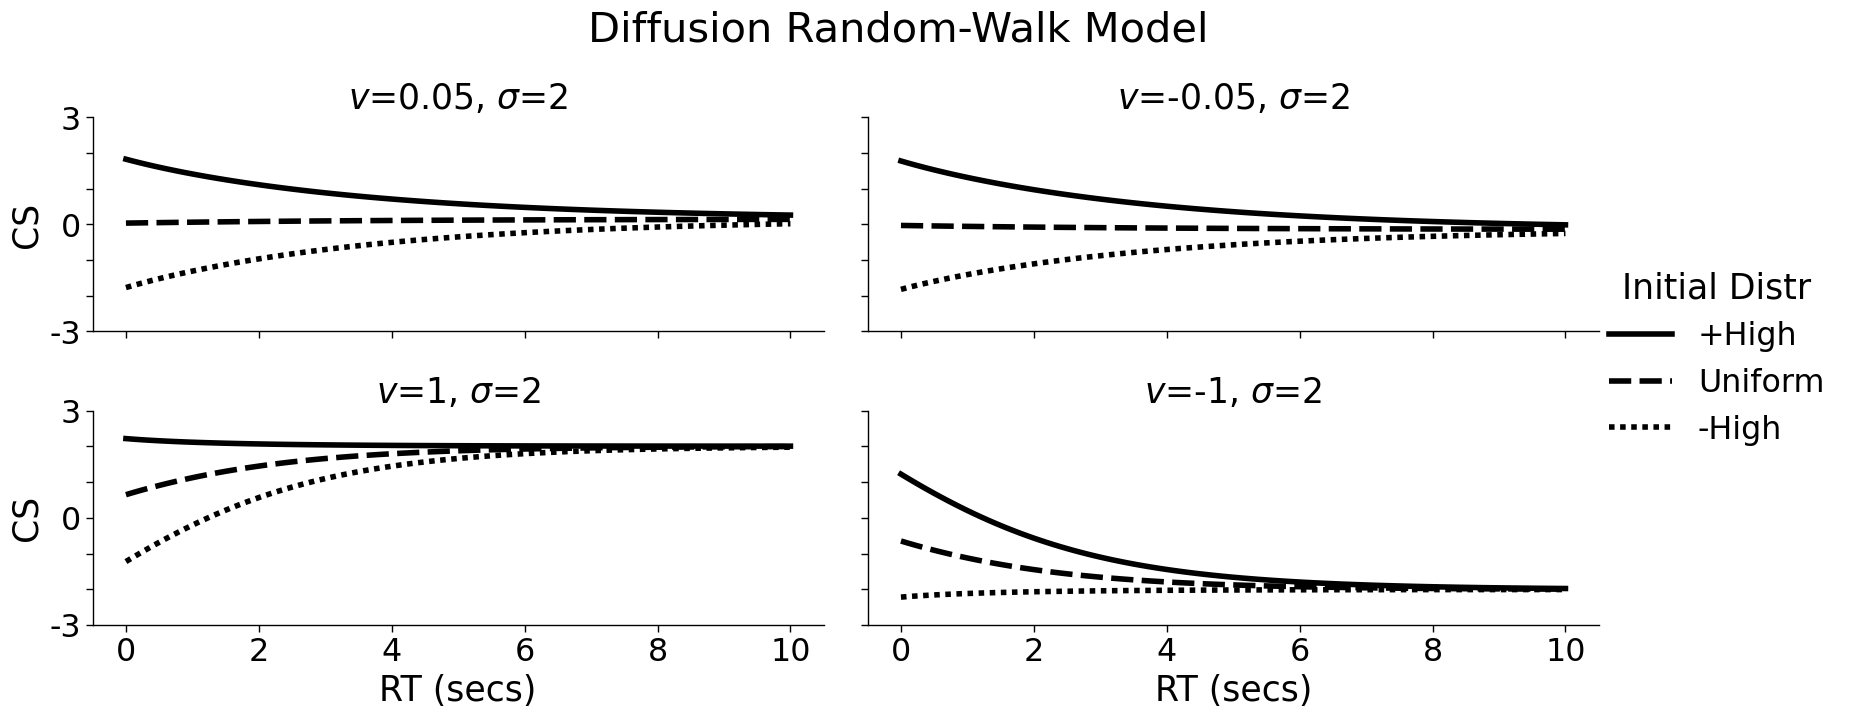

In [30]:
with sns.plotting_context("paper",font_scale=2.6):

    f = sns.relplot(df_markov1_plot.query("time <= 10"), x="time", y="value", 
                    style="prior", col="mu", color="black", col_wrap = 2, aspect=2.4, height=3.5, kind="line",lw=4)
    f.legend.set_title("Initial Distr")
    f.set_titles("{col_name}")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.figure.suptitle("Diffusion Random-Walk Model", y = 1.05)

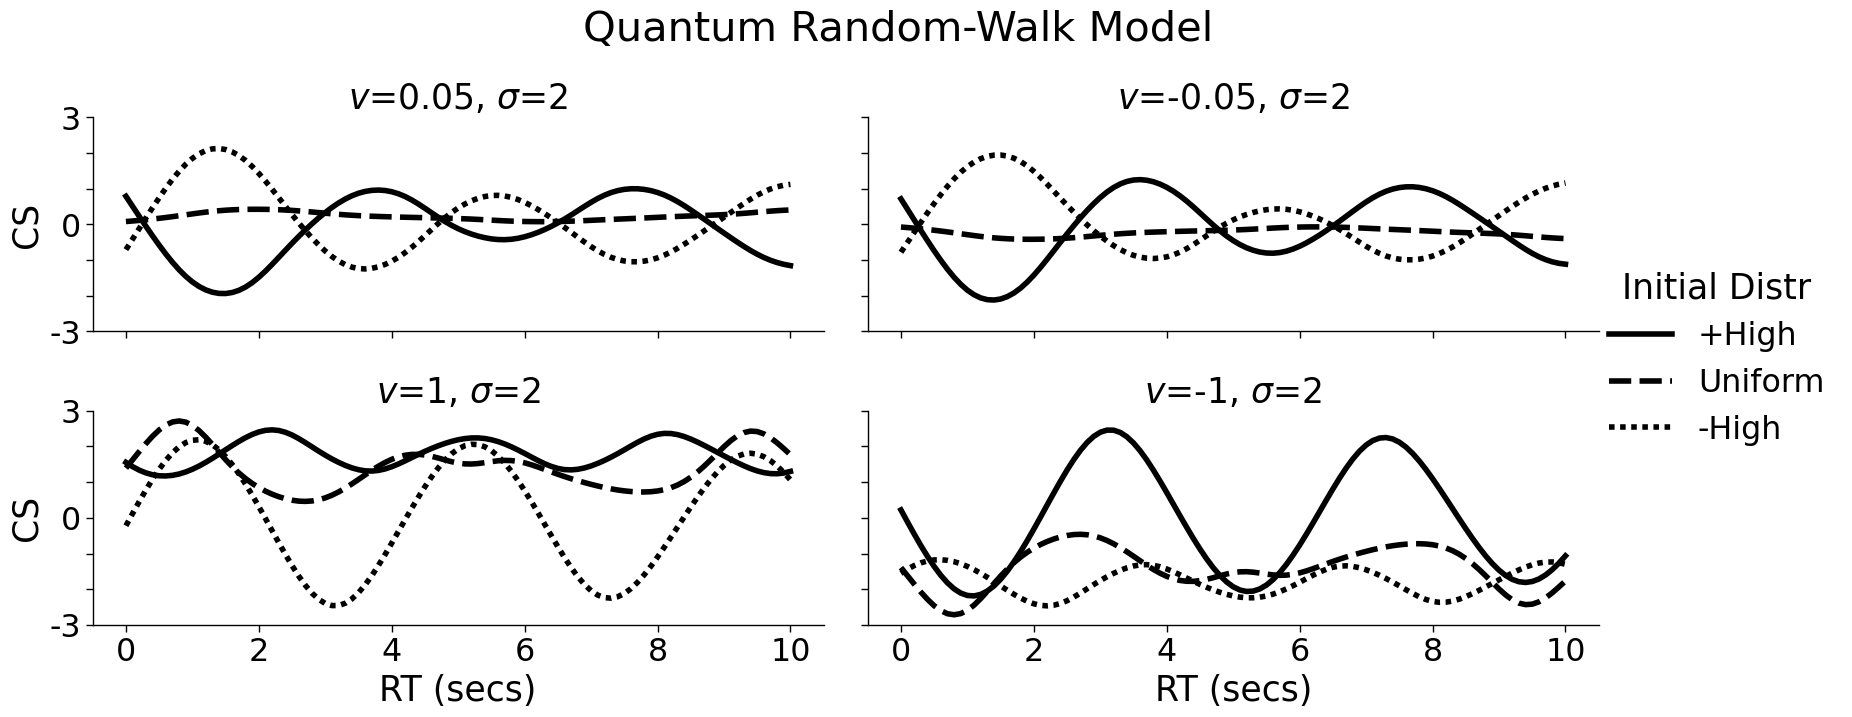

In [31]:
with sns.plotting_context("paper",font_scale=2.6):

    f = sns.relplot(df_quantum1_plot.query("time <= 10"), x="time", y="value", 
                    style="prior", col="mu", color="black", col_wrap=2, aspect=2.4, height=3.5, kind="line",lw=4)
    f.legend.set_title("Initial Distr")
    f.set_titles("{col_name}")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.figure.suptitle("Quantum Random-Walk Model", y = 1.05)

In [32]:
df_plot1 = pd.concat([df_quantum1_plot.assign(type="Quantum"), df_markov1_plot.assign(type="Diffusion")])
df_plot1

,prior,mu,time,value,type
0,+High,"$v$=0.05, $\sigma$=2",0.0,0.783978,Quantum
1,Uniform,"$v$=0.05, $\sigma$=2",0.0,0.077019,Quantum
2,-High,"$v$=0.05, $\sigma$=2",0.0,-0.710529,Quantum
3,+High,"$v$=-0.05, $\sigma$=2",0.0,0.710529,Quantum
4,Uniform,"$v$=-0.05, $\sigma$=2",0.0,-0.077019,Quantum
...,...,...,...,...,...
2275,Uniform,"$v$=1, $\sigma$=2",18.9,2.008117,Diffusion
2276,-High,"$v$=1, $\sigma$=2",18.9,2.007908,Diffusion
2277,+High,"$v$=-1, $\sigma$=2",18.9,-2.007908,Diffusion
2278,Uniform,"$v$=-1, $\sigma$=2",18.9,-2.008117,Diffusion


f = sns.relplot(df_plot1, x="time", y="value", row_order=["Diffusion", "Quantum"],
                style="prior", col="mu", row="type", color="black", aspect=1, height=4, kind="line",lw=4)
f.legend.set_title("Initial Distr")
f.set_titles("{col_name}")
f.set_xlabels("RT (secs)")
f.axes[1,0].set_ylabel("CS (Quantum)")
f.axes[1,0].set_title("")
f.axes[1,1].set_title("")
f.axes[1,2].set_title("")
f.axes[1,3].set_title("")
f.axes[0,0].set_ylabel("CS (Diffusion)")
f.set(yticks=[-3,-2,-1,0,1,2,3])
f.set_yticklabels(["-3","","","0","","","3"])



In [33]:
t = 7
t1 = 2
t2 = 1
t3 = t - (t1+t2)

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t3 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t3]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t.sum(), (m_Mc @ P_markov_t3).sum()  + (m_Mn_i @ P_markov_t2).sum() + (m_Mn_i @ P_markov_t1).sum()

NameError: name 'm_Mn_i' is not defined

In [ ]:
P_markov_t1.shape

In [ ]:
(m_Mn_i @ P_markov_t1).reshape(7,-1).shape

In [ ]:
P_markov_t.sum(), (m_Mn_i @ P_markov_t1).reshape(-1,7) @ np.eye(n_states) @ (m_Mc @ P_markov_t2).reshape(7,-1)

In [ ]:
(m_Mc @ P_markov_t2).sum()

In [ ]:
(m_Mn_i @ P_markov_t1).sum()

In [ ]:
P_markov_t.sum(), (m_Mc @ P_markov_t2).sum()  + (m_Mn_i @ P_markov_t1).sum()

In [ ]:
n=2
m_Mn_i = (npx.eye(n_states) - m_Mc)/n


In [ ]:
m_Mn_i